# Smart-G — Photon Histories & JAX post-processing

This notebook demonstrates:
- outputting per-photon histories from the ALIS correlated-spectral method,
- post-hoc gas absorption via Beer-Lambert law applied to per-photon path lengths,
- Jacobians (∂ρ/∂kabs, ∂ρ/∂T, ∂ρ/∂P) computed with `jax.grad` at zero MC cost.

> **Environment**: requires the `extra` environment (includes `jax[cuda12]` and `radis`).
> Run: `pixi run -e extra jupyter notebook`

In [1]:
%matplotlib inline
# next 2 lines allow to automatically reload modules that have been changed externally
%reload_ext autoreload
%autoreload 2
import sys, os
from pathlib import Path

# ── Make sure nvcc is on PATH (required by pycuda/smartg kernel compilation) ──
_cuda_bin = Path('/usr/local/cuda/bin')
if _cuda_bin.exists() and str(_cuda_bin) not in os.environ.get('PATH', ''):
    os.environ['PATH'] = str(_cuda_bin) + ':' + os.environ.get('PATH', '')

try:
    import subprocess
    check = subprocess.check_call(['git', 'rev-parse', '--show-toplevel'],
                                  stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT)
    ROOTPATH = subprocess.Popen(['git', 'rev-parse', '--show-toplevel'],
                                stdout=subprocess.PIPE).communicate()[0].rstrip().decode('utf-8') # Root Git Path
    ROOTPATH = Path(ROOTPATH)
except subprocess.CalledProcessError:
    ROOTPATH = Path.cwd()
sys.path.insert(0, str(ROOTPATH))

from smartg.config import DIR_AUXDATA
from smartg.smartg import Smartg, Sensor
from smartg.smartg import RoughSurface, LambSurface, FlatSurface, Environment, Albedo_cst, RTLSSurface
from smartg.atmosphere import AtmAFGL, Cloud, diff1, AerOPAC, od2k
from smartg.phase import read_phase
from smartg.water import IOP_1, IOP, IOP_profile
from smartg.albedo import Albedo_speclib, Albedo_cst, Albedo_spectrum, Albedo_map
from smartg.reptran import REPTRAN, reduce_reptran
from smartg.tools.tools import SpherIrr, Irr, reduce_Irr
from luts.luts import LUT, MLUT, Idx, merge, read_mlut
from smartg.tools.smartg_view import compare, plot_polar, spectrum , mdesc 
from smartg.tools.smartg_view import spectrum_view,transect_view,profile_view,phase_view,smartg_view,input_view
from mpl_toolkits.axes_grid1 import ImageGrid

import numpy as np
import matplotlib.pyplot as plt
import jax
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter('always', DeprecationWarning)


## Absorption spectra

- Here the extreral RADIS module is used
- It results in an vertical profile of gaseous absorption coefficient or or gaeous optical thickness at high spectral resolution

In [2]:
# ── RADIS/pandas HDF5 compatibility patches ───────────────────────────────
#
# Two problems with this version of RADIS + pandas:
#
#  (A) READ: corrupted/fixed-format cache files cause a TypeError inside
#      DataFileManager.read_metadata (via pandas HDFStore._create_storer).
#      RADIS already handles AttributeError("Attribute 'metadata' does not
#      exist") by raising DeprecatedFileWarning → auto-deleting the bad file
#      and re-downloading.  We just convert the TypeError to that AttributeError.
#
#  (B) WRITE: for some molecules (CO2, N2O, …) the `branch` column is parsed
#      as integers stored in an object array; pandas' table-format HDF5 writer
#      rejects non-string object columns.  We coerce branch to str before write.
#
from radis.api.hdf5 import DataFileManager as _DFM

# ── Patch A: read_metadata ────────────────────────────────────────────────
_orig_read_meta = _DFM.read_metadata

def _patched_read_meta(self, fname, key='df'):
    try:
        return _orig_read_meta(self, fname, key)
    except TypeError:
        # Converts pandas _TABLE_MAP KeyError (corrupt/fixed-format file)
        # into the AttributeError that RADIS uses to trigger auto-removal.
        raise AttributeError("Attribute 'metadata' does not exist")

_DFM.read_metadata = _patched_read_meta

# ── Patch B: write ────────────────────────────────────────────────────────
_orig_write = _DFM.write

def _patched_write(self, file, df, append=False, **kw):
    import pandas as _pd
    if isinstance(df, _pd.DataFrame) and 'branch' in df.columns:
        if df['branch'].dtype == object:
            import pandas.api.types as _pat
            sample = df['branch'].dropna()
            if len(sample) and not _pat.is_string_dtype(sample):
                df = df.copy()
                df['branch'] = df['branch'].astype(str)
    return _orig_write(self, file, df, append=append, **kw)

_DFM.write = _patched_write

print("RADIS patches applied (read_metadata + write).")


RADIS patches applied (read_metadata + write).


In [3]:
import warnings, logging, io, contextlib
import jax.numpy as jnp
import radis
from radis import SpectrumFactory

# ──────────────── USER PARAMETERS ─────────────────────────────────────────
MOLECULE  = 'O2'      # absorbing molecule: 'O2', 'H2O', 'CO2', 'CH4', 'N2O', 'CO', …
WL_MIN_NM = 689.    # nm  — start of high-resolution spectral grid
WL_MAX_NM = 693.     # nm  — end
NLOW_r    = 11        # number of low-resolution ALIS wavelength points

# Default VMR (volume mixing ratio) per molecule — override here if needed
_VMR_defaults = {
    'O2' : 0.2095,
    'H2O': 0.025,
    'CO2': 420e-6,
    'CH4': 1.9e-6,
    'N2O': 320e-9,
    'CO' : 0.1e-6,
}
VMR_scalar = _VMR_defaults.get(MOLECULE, 1e-6)
# ──────────────────────────────────────────────────────────────────────────

_ISOTOPES = {
    'O2' : '1',       'H2O': '1,2,3',  'CO2': '1,2,3,4',
    'CH4': '1,2',     'N2O': '1,2,3,4,5',  'CO': '1,2',
}
ISOTOPE = _ISOTOPES.get(MOLECULE, '1')

# ── vertical grid: interface altitudes (NZ=9) ─────────────────────────────
_afglt_grid = np.array([100., 75., 50., 30., 20., 10., 5., 2., 1., 0.])  # km
_prof       = AtmAFGL('afglt', grid=_afglt_grid.tolist()).prof
z_iface     = _afglt_grid
z_mid       = 0.5 * (z_iface[:-1] + z_iface[1:])   # (NL=8,) layer midpoints
T_mid       = np.interp(z_mid, _prof.z[::-1], _prof.T[::-1])
P_mid       = np.interp(z_mid, _prof.z[::-1], _prof.P[::-1])
n_mid       = np.interp(z_mid, _prof.z[::-1], _prof.dens_air[::-1])
thick       = np.abs(np.diff(z_iface))  # (NL=8,) layer thicknesses in km
NL_layers   = len(z_mid)

# ── VMR vertical profile (NL,) ────────────────────────────────────────────
# O2, CO2, CH4, … are well-mixed; H2O scales approximately with pressure.
_vmr_profiles = {
    'O2' : VMR_scalar * np.ones(NL_layers),
    'H2O': VMR_scalar * (P_mid / P_mid[-1]),     # surface-pressure scaling
}
VMR_profile = _vmr_profiles.get(MOLECULE, VMR_scalar * np.ones(NL_layers))

# ── Wavenumber range (from user wavelength bounds) ─────────────────────────
wn_min = float(1e7 / WL_MAX_NM) - 1.
wn_max = float(1e7 / WL_MIN_NM) + 1.

# ── O₂-A band HR grid & ALIS low-res grid ─────────────────────────────────
wl_hr   = np.array([WL_MIN_NM, WL_MAX_NM])   # placeholder; updated from RADIS output
wl_lr_r = np.linspace(WL_MIN_NM, WL_MAX_NM, NLOW_r)

# ── SpectrumFactory + HITRAN download (once, then cached) ─────────────────
_sink = io.StringIO()
radis.config['SPARSE_WAVERANGE'] = False
with warnings.catch_warnings(), contextlib.redirect_stdout(_sink), contextlib.redirect_stderr(_sink):
    warnings.simplefilter('ignore')
    logging.disable(logging.CRITICAL)
    sfac = SpectrumFactory(
        wavenum_min=wn_min, wavenum_max=wn_max,
        molecule=MOLECULE, isotope=ISOTOPE,
        mole_fraction=1.0,
        wstep='auto',      # auto-selects grid step fine enough for narrowest line
        verbose=False, warnings={},
    )
    sfac.fetch_databank('hitran')   # downloads once; uses ~/.radis/ cache afterwards
    logging.disable(logging.NOTSET)
print(f"SpectrumFactory ready — {MOLECULE} (isotope {ISOTOPE}, VMR_scalar={VMR_scalar:.4g})")

# ── Absorption coefficient per layer ──────────────────────────────────────
# wstep='auto' may choose a slightly different grid size per T/P condition,
# so we establish a reference wavelength grid from the first layer and
# interpolate all subsequent layers onto it.
sigma_layers = []
_wl_ref = None
with warnings.catch_warnings(), contextlib.redirect_stdout(_sink), contextlib.redirect_stderr(_sink):
    warnings.simplefilter('ignore')
    logging.disable(logging.CRITICAL)
    for k in range(NL_layers):
        vmr_k = float(VMR_profile[k])
        s = sfac.eq_spectrum(
            Tgas=float(T_mid[k]),
            pressure=float(P_mid[k]) * 1e-3,   # hPa → bar
            mole_fraction=vmr_k,
        )
        wn_out, sigma_k = s.get('xsection')
        wl_out_k = 1e7 / wn_out[::-1]          # ascending wavelength
        sigma_k  = sigma_k[::-1]                # align with wl_out_k
        if _wl_ref is None:
            _wl_ref = wl_out_k                  # fix reference grid from layer 0
        else:
            sigma_k = np.interp(_wl_ref, wl_out_k, sigma_k)  # resample onto ref
        n_k = vmr_k * n_mid[k]                  # [molec/cm³]
        sigma_layers.append(sigma_k * n_k * 1e5)  # cm⁻¹ → km⁻¹
    logging.disable(logging.NOTSET)

wl_hr   = _wl_ref                                                               # (NWL_HR,)
kabs_hr = jnp.array(np.stack(sigma_layers, axis=1), dtype=jnp.float32)         # (NWL_HR, NL=8)
wl_lr_r = np.linspace(wl_hr.min(), wl_hr.max(), NLOW_r)                        # update to match wl_hr

# ── prof_abs: shape (NWL_HR, NZ=9) matching prof.z ────────────────────────
# diff1 pads dz[0]=0 at TOA → prepend a zero column before the NL layer ODs.
_layer_od = np.array(kabs_hr) * thick[np.newaxis, :]                            # (NWL_HR, 8)
prof_abs  = np.concatenate(
    [np.zeros((len(wl_hr), 1), dtype='float32'), _layer_od], axis=1)            # (NWL_HR, 9)

print(f"wl_hr     : [{wl_hr.min():.3f}, {wl_hr.max():.3f}] nm,  {len(wl_hr)} points")
print(f"kabs_hr   : {kabs_hr.shape}  max = {float(kabs_hr.max()):.3e} km⁻¹")
print(f"prof_abs  : {prof_abs.shape}  max = {prof_abs.max():.3e}  (layer OD, col 0 = TOA zero)")


SpectrumFactory ready — O2 (isotope 1, VMR_scalar=0.2095)
wl_hr     : [688.952, 693.048] nm,  9532 points
kabs_hr   : (9532, 9)  max = 1.612e+00 km⁻¹
prof_abs  : (9532, 10)  max = 1.317e+01  (layer OD, col 0 = TOA zero)


Box(children=(FloatProgress(value=0.0, max=95320000.0), Label(value='')), layout=Layout(align_items='center', …

 GPU time:  0.4930894079208374 s
CPU times: user 1.07 s, sys: 136 ms, total: 1.21 s
Wall time: 1.67 s


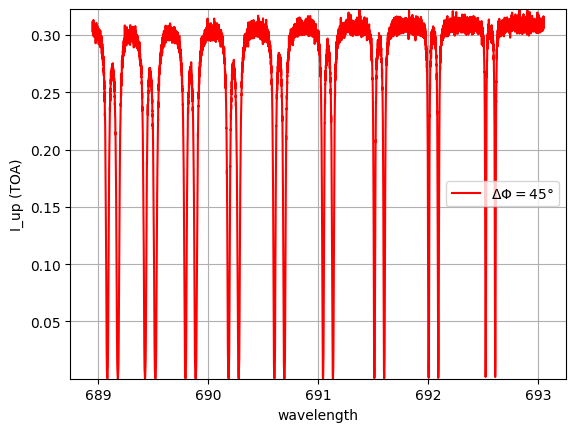

In [4]:
%%time
# multispectral simulation
# computation done independently for each wavelegnth, NBPHOTONS is shared equally
# between all wavelegths (thus Monte Carlo NOISE in the spectrum)
# wavelengths is a list or numpy array
NWL= wl_hr.size
NB = 1e4 # photons per wavelength
SEED = 1234  # fixed seed — identical for all runs (hist=True/False comparisons)
# monochromatic computation for custom aerosols and cloud
wl0 = 690.
# Aerosols and cloud optical properties using OPAC database as processed by the the libradtran (www.libradtran.org)
aer1 = AerOPAC( 'maritime_clean',  0.3, wl0) # set AOT at the reference wavelength wl0 to 0.5 
                                # and set aerosol type to 'maritime_clean'
pro = AtmAFGL('afglt',    # tropical atmosphere with O2 absorption in the O2-A band
              comp   = [aer1], # particles in atmosphere are a mix of aerosols 1 and 2            
              grid   = _afglt_grid, # set vertical grid, surface altitude at 1.15 km
              pfgrid = [100, 10, 5, 2., 0.],           
              pfwav  = [wl0], # wavelengths for which the phase function is computed
                                     # optional, otherwise phase functions are calculated at all bands
                                     # nearest neighbour is then used during the RT computation
              NO2 = False, # NO2 included
              O3  = 0., # no ozone
              prof_abs = prof_abs   # (NWL_HR, NL) layer OD = kabs_hr * thick
             )
pro0 = AtmAFGL('afglt',    # tropical atmosphere, no gaseous absorption
              comp   = [aer1], # particles in atmosphere are a mix of aerosols 1 and 2            
              grid   = _afglt_grid, # set vertical grid, surface altitude at 1.15 km
              pfgrid = [100, 10, 5, 2., 0.],           
              pfwav  = [wl0], # wavelengths for which the phase function is computed
                                     # optional, otherwise phase functions are calculated at all bands
                                     # nearest neighbour is then used during the RT computation
              NO2 = False, # NO2 included
              O3  = 0., # no ozone
             )

le={'zip':False}
ALBEDO = 0.3
GREY_ALB = Albedo_cst(ALBEDO)
surf = LambSurface(ALB=GREY_ALB)
SZA, VZA = 60., 30.
le.update(th = np.array([VZA]) *np.pi/180)
le.update(phi= np.array([45.]) *np.pi/180)
mc = Smartg(alt_pp=True, double=True).run(wl=wl_hr, le=le,
           THVDEG=SZA, NBPHOTONS=NB*NWL, SEED=SEED,
           atm=pro, OUTPUT_LAYERS=1,
           surf=surf).dropaxis('Azimuth angles')
mc['I_up (TOA)'].sub()[:,0].plot(fmt='-r', label=r'$\Delta\Phi=${:.0f}°'.format(le['phi'][0]*180/np.pi))
plt.legend()
print(' GPU time: ', mc.attrs['kernel time (s)'], 's')


### Correlated spectral computations: ALIS method 
The ALIS method is described in <br>
Emde, C., Buras, R., and Mayer, B.: ALIS: An efficient method to
compute high spectral resolution polarized solar radiances using the Monte Carlo approach, J. Quant. Spectrosc. Ra., 112, 1622–1631, 2011.

Box(children=(FloatProgress(value=0.0, max=10000.0), Label(value='')), layout=Layout(align_items='center', dis…

 GPU time:  0.39116610717773437 s
CPU times: user 881 ms, sys: 43 ms, total: 924 ms
Wall time: 1.01 s


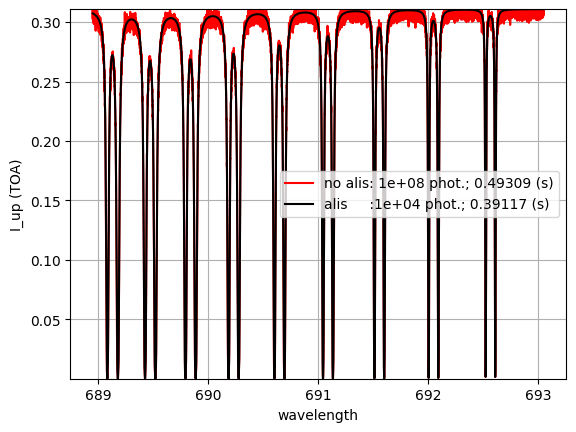

In [5]:
%%time
# Compile with the alis options
Salis = Smartg(alt_pp=True, double=True, alis=True) # with ALIS options, alt_pp is mandatory
# then run specifying the alis_options dictionary
# main keyword is 'nlow' , the number of low spectral resolution computation
# of the scattering correction terms: specify -1 for all wavelengths
# if the alt_pp option is chosen for compilation: slowest procedure for photon propagation but
# then the cumulative distance traveled by photons in the atmospheric layer is recorded
alis_options = {'nlow':wl_lr_r.size, 'hist': False} # specify the number of low spectral resolution computations for the scattering correction terms
# and does not export photon histories
m = Salis.run(wl=wl_hr, le=le, alis_options=alis_options,
           THVDEG=SZA, NBPHOTONS=NB, SEED=SEED, stdev=True, NBLOOP=NB,
           atm=mc, OUTPUT_LAYERS=0,
           surf=surf).dropaxis('Azimuth angles')

# for the same number of photons, the spectrum is much less noisy
mc['I_up (TOA)'].sub()[:,0].plot(fmt='-r', label='no alis: {:.0e} phot.; {:.5f} (s)'.format(NB*NWL,float(mc.attrs['kernel time (s)'])))
m ['I_up (TOA)'].sub()[:,0].plot(fmt='-k', label='alis     :{:.0e} phot.; {:.5f} (s)'.format(NB,float(m.attrs['kernel time (s)'])))
plt.legend()
#plt.ylim(0.21,0.27)
print(' GPU time: ', m.attrs['kernel time (s)'], 's')


### Histories

In [ ]:
from smartg.histories import get_histories, BigSum, Si, Si2, compute_amf
# Scatter-class count for AMF decomposition (used for both GPU and post-hoc paths).
# Defined here so cells 12 and 23 share it regardless of execution order.
nscl = int(_afglt_grid.size)   # = 10 = number of atmospheric layers
# We give an example of outputing photon's histories in the alis method.
# This allows to compute various quantities jacobians relative to absorption or reflection
# see Multispectral example (output m)
# We extract the absorption coefficient vertical profiles at high spectral resolution
kabs = od2k(m, 'OD_abs_atm')[:,1:]
Salis = Smartg(alt_pp=True, double=True, alis=True) 
# Computations of histories are done on the low resolution grid (only scattering !)
# !! NBLOOP and NBPHOTONS should be equal (one UNIQUE pass)
# the surface albedo as to be set to 1. Reflection is computed afterwards using the photon histories 
# and the high resolution albedos
surf_hist = LambSurface(ALB=Albedo_cst(1.))
alis_options = {'nlow':wl_lr_r.size, 'hist':True, 'max_hist':np.int64(NB*30)} # specify the number of 
# low spectral resolution 
# computations for the scattering correction terms, phtons histories are recorded and the maximum 
# number of histories is set to NB*10 
# (to avoid memory overflow)
atm = pro0.calc(wl_lr_r) # we use the low resolution grid for the atmospheric properties (absorption and scattering)

In [7]:
%%time
Salis = Smartg(alt_pp=True, double=True, alis=True) 
m_hist=Salis.run(wl=wl_lr_r, le=le, alis_options=alis_options,
        THVDEG=SZA, NBPHOTONS=NB, NBLOOP=NB, SEED=SEED,
        atm =atm, OUTPUT_LAYERS=1,
        surf=surf_hist)  
print("m_hist {:.2g} photons : {:.5f} (ms)".format(NB, float(m_hist.attrs['kernel time (s)'])*1000))


Box(children=(FloatProgress(value=0.0, max=10000.0), Label(value='')), layout=Layout(align_items='center', dis…

m_hist 1e+04 photons : 2.60538 (ms)
CPU times: user 398 ms, sys: 67.9 ms, total: 466 ms
Wall time: 553 ms


In [19]:
%%time
# ─── hist=False: GPU computes cdist/tabDist directly ──────────────────────
# Compile Smartg with AMF options — mirrors the post-hoc parameters used below.
# Must run BEFORE Salis.clear_context() (JAX init in the next cell).
nscl   = int(_afglt_grid.size)   # 10 = number of atm layers
Samf   = Smartg(alt_pp=True, double=True, alis=True,
                amf_variance=True, nscl=nscl,
                scatter_classes='scattering_order_per_layer', norders=2)
m_amf  = Samf.run(wl=wl_lr_r, le=le,
                  alis_options={'nlow': wl_lr_r.size, 'hist': False},
                  THVDEG=SZA, NBPHOTONS=NB, NBLOOP=NB, SEED=SEED,
                  atm=atm, OUTPUT_LAYERS=1,
                  surf=surf_hist)
print(f"m_amf  {NB:.2g} photons : {float(m_amf.attrs['kernel time (s)'])*1000:.3f} ms")
print(f"cdist axes = {list(m_amf['cdist_up (TOA)'].names)}")

Box(children=(FloatProgress(value=0.0, max=10000.0), Label(value='')), layout=Layout(align_items='center', dis…

m_amf  1e+04 photons : 5.585 ms
cdist axes = ['None', 'Azimuth angles', 'Zenith angles', 'iSCL', 'iAMF']
CPU times: user 435 ms, sys: 121 ms, total: 556 ms
Wall time: 1.06 s


[CudaDevice(id=0)]
CPU times: user 730 ms, sys: 240 ms, total: 970 ms
Wall time: 898 ms


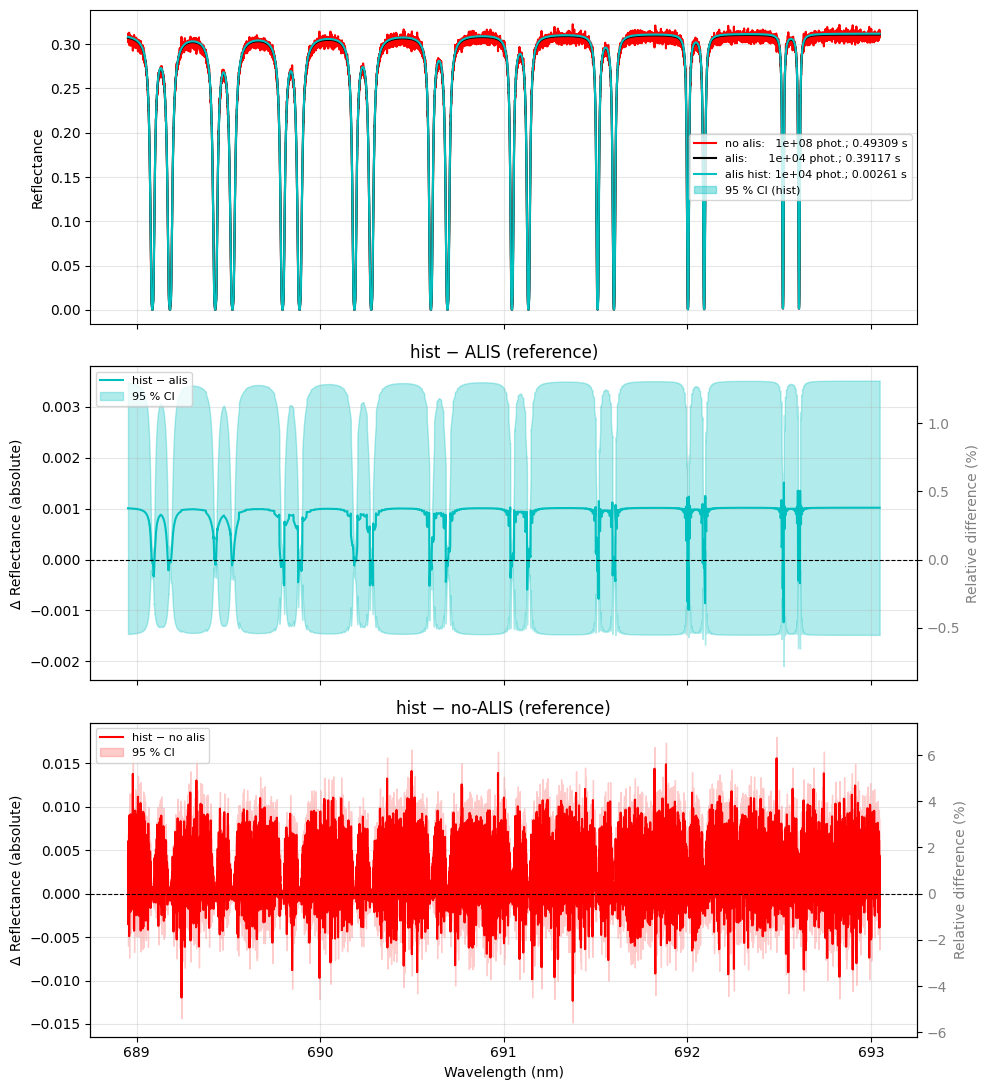

In [9]:
%%time
# Since always autoinit = True used until now, only 1 current context
# We can clear manually the context (!!! all previous Smartg object cannot be reused, they must be reinitialized !!!)
Salis.clear_context() # now we can use jax
import os
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'platform'
from jax import jit, vmap
import jax.lax as lax
jax.default_backend()
print(jax.devices())

# LEVEL = 0 for TOA, 1 for downward at 0+
N_h, S_h, D_h, w_h, nrrs_h, nref_h, nsif_h, nvrs_h, nenv_h, nint_h, nlscl_h = get_histories(m_hist, LEVEL=0, verbose=False)
# nlscl_h : last-scattering layer index per photon (-1 = unscattered/surface reflection)

# Upload to JAX device (GPU) once
S_h    = jnp.array(S_h)     # (NLE, NStokes)
D_h    = jnp.array(D_h)     # (NLE, NL)
w_h    = jnp.array(w_h)     # (NLE, NLR)
nref_h = jnp.array(nref_h)  # (NLE,)

# ── Shared per-photon kernel (reused by all subsequent Jacobian cells) ────
kabs_j   = jnp.array(kabs,               dtype=jnp.float32)  # (NWL_HR, NL)
wl_hr_j  = jnp.array(wl_hr,              dtype=jnp.float32)  # (NWL_HR,)
alb_hr_j = jnp.array(GREY_ALB.get(wl_hr),dtype=jnp.float32)  # (NWL_HR,)

def _si_one(sik, wi_lr, Dij, Ki, wl_i, kabs_i, alb_i):
    """Beer-Lambert weight: one Stokes component, one photon, one wavelength."""
    wi = jnp.interp(wl_i, wl_lr_r, wi_lr)
    return sik * wi * jnp.exp(-jnp.sum(Dij * kabs_i)) * alb_i**Ki

_si_photons = vmap(_si_one, in_axes=(0, 0, 0, 0, None, None, None))  # over NLE photons
_si_stokes  = vmap(_si_photons, in_axes=(1, None, None, None, None, None, None))  # over NStokes
# _si_stokes(S_h, w_h, D_h, nref_h, wl_scalar, kabs_1d, alb_scalar) → (NStokes, NLE)

_N_h    = float(N_h)
NWL     = int(kabs_j.shape[0])
NL_     = int(kabs_j.shape[1])
NStokes_ = int(S_h.shape[1])

# ── Forward Stokes + variance via fori_loop ───────────────────────────────
# fori_loop → XLA while_loop; XLA does NOT pre-allocate backward checkpoints
# → no rematerialization warning
def _body_fw(i, carry):
    s_sum, s2_sum = carry
    si = _si_stokes(S_h, w_h, D_h, nref_h, wl_hr_j[i], kabs_j[i], alb_hr_j[i])  # (NStokes, NLE)
    return s_sum.at[i].set(si.sum(axis=1)), s2_sum.at[i].set((si**2).sum(axis=1))

stokes_j, stokes2_j = jit(
    lambda: lax.fori_loop(0, NWL, _body_fw,
                          (jnp.zeros((NWL, NStokes_)), jnp.zeros((NWL, NStokes_))))
)()
Stokes  = np.array(stokes_j).T / _N_h   # (NStokes, NWL_HR)
Stokes2 = np.array(stokes2_j).T / _N_h  # (NStokes, NWL_HR)

Std   = np.sqrt((Stokes2 - Stokes**2) / _N_h)
upper = Stokes + 1.95*Std
lower = Stokes - 1.95*Std

# Extract data arrays from LUT objects
wl_mc   = mc.axis('wavelength')
I_mc    = mc['I_up (TOA)'].sub()[:,0].data
wl_alis = m.axis('wavelength')
I_alis  = m['I_up (TOA)'].sub()[:,0].data   # same wavelength grid as wl_hr
I_hist  = Stokes[0,:]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 11), sharex=True)

# ── Top: spectra ───────────────────────────────────────────────────────────
ax1.plot(wl_mc,   I_mc,   '-r', label='no alis:   {:.0e} phot.; {:.5f} s'.format(NB*NWL, float(mc.attrs['kernel time (s)'])))
ax1.plot(wl_alis, I_alis, '-k', label='alis:      {:.0e} phot.; {:.5f} s'.format(NB,     float(m.attrs['kernel time (s)'])))
ax1.plot(wl_hr,   I_hist, '-c', label='alis hist: {:.0e} phot.; {:.5f} s'.format(NB,     float(m_hist.attrs['kernel time (s)'])))
ax1.fill_between(wl_hr, lower[0,:], upper[0,:], facecolor='c', edgecolor='c', alpha=0.4, label='95 % CI (hist)')
ax1.set_ylabel('Reflectance')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ── Middle: hist − alis ────────────────────────────────────────────────────
alis_ref = np.interp(wl_hr, wl_alis, I_alis)
diff_alis       = I_hist  - alis_ref
diff_alis_upper = upper[0,:] - alis_ref
diff_alis_lower = lower[0,:] - alis_ref
rel_alis        = 100. * diff_alis       / alis_ref
rel_alis_upper  = 100. * diff_alis_upper / alis_ref
rel_alis_lower  = 100. * diff_alis_lower / alis_ref

ax2.plot(wl_hr, diff_alis, '-c', lw=1.5, label='hist − alis')
ax2.fill_between(wl_hr, diff_alis_lower, diff_alis_upper, facecolor='c', edgecolor='c', alpha=0.3, label='95 % CI')
ax2.axhline(0, color='k', lw=0.8, ls='--')
ax2.set_ylabel('Δ Reflectance (absolute)')
ax2.set_title('hist − ALIS (reference)')
ax2.legend(fontsize=8, loc='upper left')
ax2.grid(True, alpha=0.3)
ax2r = ax2.twinx()
ax2r.set_ylabel('Relative difference (%)', color='grey')
ax2r.tick_params(axis='y', labelcolor='grey')
ax2r.set_ylim(100. * np.array(ax2.get_ylim()) / np.mean(alis_ref))

# ── Bottom: hist − no alis ─────────────────────────────────────────────────
mc_ref          = np.interp(wl_hr, wl_mc, I_mc)
diff_mc         = I_hist  - mc_ref
diff_mc_upper   = upper[0,:] - mc_ref
diff_mc_lower   = lower[0,:] - mc_ref
rel_mc          = 100. * diff_mc       / mc_ref
rel_mc_upper    = 100. * diff_mc_upper / mc_ref
rel_mc_lower    = 100. * diff_mc_lower / mc_ref

ax3.plot(wl_hr, diff_mc, '-r', lw=1.5, label='hist − no alis')
ax3.fill_between(wl_hr, diff_mc_lower, diff_mc_upper, facecolor='r', edgecolor='r', alpha=0.2, label='95 % CI')
ax3.axhline(0, color='k', lw=0.8, ls='--')
ax3.set_xlabel('Wavelength (nm)')
ax3.set_ylabel('Δ Reflectance (absolute)')
ax3.set_title('hist − no-ALIS (reference)')
ax3.legend(fontsize=8, loc='upper left')
ax3.grid(True, alpha=0.3)
ax3r = ax3.twinx()
ax3r.set_ylabel('Relative difference (%)', color='grey')
ax3r.tick_params(axis='y', labelcolor='grey')
ax3r.set_ylim(100. * np.array(ax3.get_ylim()) / np.mean(mc_ref))

plt.tight_layout()


### Pure-scattering run + post-hoc gas absorption (RADIS / Beer-Lambert via histories)

Run SmartG **once** in pure-scattering mode (no gas absorption).  
Per-photon path lengths `U[Nph, NL]` and weights `w[Nph]` are stored.  
Any cross-section `σ(ν̃, T_k, P_k)` from **RADIS** (or AtmAFGL fallback) is then applied post-hoc:

$$\tau_i(\tilde\nu) = \mathbf{U}_i \cdot \boldsymbol{\sigma}(\tilde\nu) \qquad W_i = e^{-\tau_i} \qquad \rho(\tilde\nu) = \frac{\mathbf{w}^\top \mathbf{W}}{\sum w_i}$$

Jacobians $\partial\rho/\partial c$ and SRF convolution come **for free** via `jax.grad`.

SRF-convolved reflectance at 759.7 nm (FWHM=0.3 nm): nan
CPU times: user 646 ms, sys: 154 ms, total: 800 ms
Wall time: 685 ms


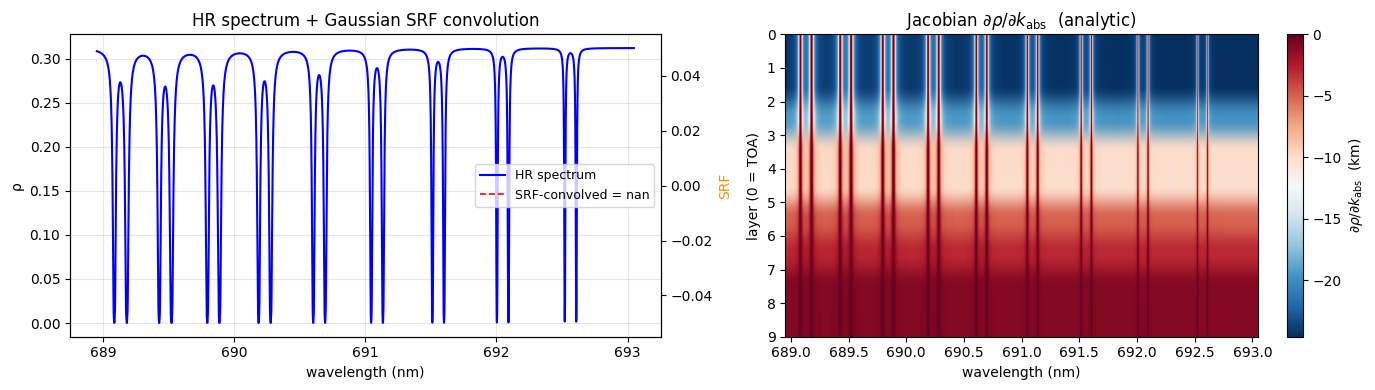

In [10]:
%%time
# Stokes-I spectrum + ∂ρ_I/∂kabs via analytic gradient + fori_loop
#
# kabs_j, wl_hr_j, alb_hr_j, _si_stokes, _N_h, NWL, NL_ defined in cell 9.
#
# Analytic: ∂Si/∂kabs[l] = -D_i[l]·Si  →  ∂ρ_I/∂kabs[l] = -Σᵢ D_h[i,l]·si_I[i] / N

def _body_I(i, carry):
    rho_arr, jac_arr = carry
    si = _si_stokes(S_h, w_h, D_h, nref_h, wl_hr_j[i], kabs_j[i], alb_hr_j[i])  # (NStokes, NLE)
    rho_i = jnp.sum(si[0]) / _N_h                  # scalar
    jac_i = -jnp.dot(D_h.T, si[0]) / _N_h          # (NL,)
    return rho_arr.at[i].set(rho_i), jac_arr.at[i].set(jac_i)

rho_jax_j, dI_dkabs_j = jit(
    lambda: lax.fori_loop(0, NWL, _body_I,
                          (jnp.zeros(NWL), jnp.zeros((NWL, NL_))))
)()
rho_jax  = np.array(rho_jax_j)    # (NWL_HR,)
dI_dkabs = np.array(dI_dkabs_j)   # (NWL_HR, NL)

# ── SRF convolution ───────────────────────────────────────────────────────
wl_c, fwhm = 759.7, 0.3
sig   = fwhm / (2 * np.sqrt(2 * np.log(2)))
srf   = np.exp(-0.5 * ((wl_hr - wl_c) / sig)**2)
srf  /= np.trapezoid(srf, wl_hr)
rho_conv = float(np.trapezoid(srf * rho_jax, wl_hr))
print(f"SRF-convolved reflectance at {wl_c} nm (FWHM={fwhm} nm): {rho_conv:.5f}")

# ── Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(wl_hr, rho_jax, 'b-', lw=1.5, label='HR spectrum')
axes[0].axhline(rho_conv, color='r', ls='--', lw=1.2,
                label=f'SRF-convolved = {rho_conv:.4f}')
ax2 = axes[0].twinx()
ax2.fill_between(wl_hr, srf, alpha=0.20, color='orange')
ax2.set_ylabel('SRF', color='darkorange')
axes[0].set_xlabel('wavelength (nm)'); axes[0].set_ylabel('ρ')
axes[0].set_title('HR spectrum + Gaussian SRF convolution')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

im = axes[1].imshow(dI_dkabs.T, aspect='auto', origin='upper',
                    extent=[wl_hr[0], wl_hr[-1], dI_dkabs.shape[1], 0],
                    cmap='RdBu_r')
plt.colorbar(im, ax=axes[1], label=r'$\partial\rho/\partial k_\mathrm{abs}$  (km)')
axes[1].set_xlabel('wavelength (nm)'); axes[1].set_ylabel('layer (0 = TOA)')
axes[1].set_title(r'Jacobian $\partial\rho/\partial k_\mathrm{abs}$  (analytic)')

plt.tight_layout()

kabs_T: (9532, 9),  max = 1.612e+00 km⁻¹
max |∂ρ/∂T_O2|   = 4.225e-05 K⁻¹
max |∂ρ/∂VMR_O2| = 1.281e-01


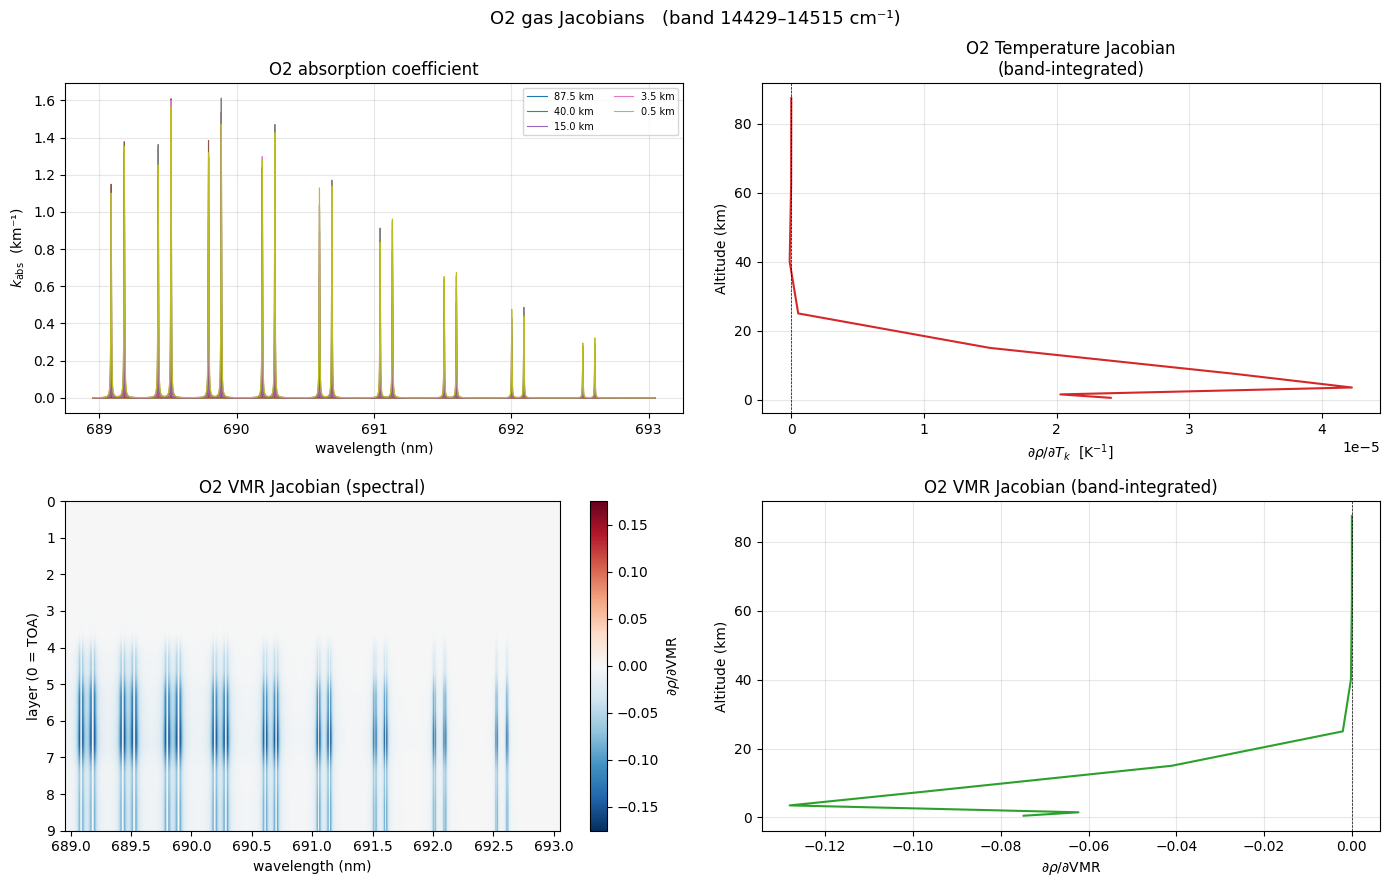

CPU times: user 548 ms, sys: 39.2 ms, total: 587 ms
Wall time: 601 ms


In [11]:
%%time
# ─── Gas Absorber Jacobians  ∂ρ/∂T  and  ∂ρ/∂VMR ─────────────────────────
#
# Inherits from cell 4:  MOLECULE, wn_min, wn_max, sfac, VMR_profile,
#                         NL_layers, T_mid, P_mid, n_mid, z_mid, wl_hr
#
# Computes:
#   ∂ρ/∂T_k(ν)     — temperature Jacobian   (forward-difference ΔT = 1 K)
#   ∂ρ/∂VMR_k(ν)   — concentration Jacobian (analytical, linear in VMR)

import warnings, logging, io, contextlib
import jax.numpy as jnp

DeltaT = 1.0    # K  (forward-difference step for T-Jacobian)
_sink = io.StringIO()

# ── 1. kabs per layer at reference T and T+ΔT ─────────────────────────────
kabs_T   = np.zeros((len(wl_hr), NL_layers), dtype='float32')
kabs_TdT = np.zeros_like(kabs_T)

with warnings.catch_warnings(), contextlib.redirect_stdout(_sink), contextlib.redirect_stderr(_sink):
    warnings.simplefilter('ignore')
    logging.disable(logging.CRITICAL)
    for k_idx in range(NL_layers):
        vmr_k = float(VMR_profile[k_idx])
        P_bar = float(P_mid[k_idx]) * 1e-3          # hPa → bar
        n_k   = vmr_k * n_mid[k_idx]               # number density [molec/cm³]

        s0 = sfac.eq_spectrum(Tgas=float(T_mid[k_idx]),            pressure=P_bar, mole_fraction=vmr_k)
        wn0, x0 = s0.get('xsection'); wl_s0 = 1e7 / wn0[::-1]
        kabs_T[:, k_idx] = np.interp(wl_hr, wl_s0, x0[::-1]) * n_k * 1e5

        s1 = sfac.eq_spectrum(Tgas=float(T_mid[k_idx]) + DeltaT, pressure=P_bar, mole_fraction=vmr_k)
        wn1, x1 = s1.get('xsection'); wl_s1 = 1e7 / wn1[::-1]
        kabs_TdT[:, k_idx] = np.interp(wl_hr, wl_s1, x1[::-1]) * n_k * 1e5

    logging.disable(logging.NOTSET)

print(f"kabs_T: {kabs_T.shape},  max = {kabs_T.max():.3e} km⁻¹")

# ── 2. T-Jacobian via chain rule ───────────────────────────────────────────
dkabs_dT   = (kabs_TdT - kabs_T) / DeltaT                        # (NWL, NL) km⁻¹/K
dkabs_dT_j = jnp.array(dkabs_dT, dtype=jnp.float32)
dI_dkabs_j = jnp.array(dI_dkabs, dtype=jnp.float32)
drho_dT_wl = dI_dkabs_j * dkabs_dT_j
dwl        = float(wl_hr[1] - wl_hr[0])
drho_dT    = np.array(jnp.sum(drho_dT_wl, axis=0) * dwl)         # (NL,)
print(f"max |∂ρ/∂T_{MOLECULE}|   = {np.abs(drho_dT).max():.3e} K⁻¹")

# ── 3. VMR-Jacobian (analytical: kabs ∝ VMR) ──────────────────────────────
with np.errstate(divide='ignore', invalid='ignore'):
    dkabs_dVMR = np.where(VMR_profile[None, :] > 0,
                          kabs_T / VMR_profile[None, :], 0.)       # (NWL, NL)
drho_dVMR_wl = dI_dkabs * dkabs_dVMR
drho_dVMR    = drho_dVMR_wl.sum(axis=0) * dwl                     # (NL,)
print(f"max |∂ρ/∂VMR_{MOLECULE}| = {np.abs(drho_dVMR).max():.3e}")

# ── 4. Plots ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f'{MOLECULE} gas Jacobians   (band {wn_min:.0f}–{wn_max:.0f} cm⁻¹)', fontsize=13)

# [0,0] kabs spectrum per layer
for k_idx in range(NL_layers):
    axes[0, 0].plot(wl_hr, kabs_T[:, k_idx], lw=0.8,
                    label=f'{z_mid[k_idx]:.1f} km' if k_idx % 2 == 0 else None)
axes[0, 0].set_xlabel('wavelength (nm)')
axes[0, 0].set_ylabel(r'$k_\mathrm{abs}$  (km⁻¹)')
axes[0, 0].set_title(f'{MOLECULE} absorption coefficient')
axes[0, 0].legend(fontsize=7, ncol=2)
axes[0, 0].grid(True, alpha=0.3)

# [0,1] ∂ρ/∂T profile
axes[0, 1].plot(drho_dT, z_mid, color='C3', lw=1.5)
axes[0, 1].axvline(0, color='k', lw=0.5, ls='--')
axes[0, 1].set_xlabel(r'$\partial\rho/\partial T_k$  [K$^{-1}$]')
axes[0, 1].set_ylabel('Altitude (km)')
axes[0, 1].set_title(f'{MOLECULE} Temperature Jacobian\n(band-integrated)')
axes[0, 1].grid(True, alpha=0.3)

# [1,0] ∂ρ/∂VMR spectral heatmap
vmax_v = float(np.abs(drho_dVMR_wl).max()) or 1e-30
im0 = axes[1, 0].imshow(drho_dVMR_wl.T, aspect='auto', origin='upper',
                        extent=[wl_hr[0], wl_hr[-1], NL_layers, 0],
                        cmap='RdBu_r', vmin=-vmax_v, vmax=vmax_v)
plt.colorbar(im0, ax=axes[1, 0], label=r'$\partial\rho/\partial\mathrm{VMR}$')
axes[1, 0].set_xlabel('wavelength (nm)')
axes[1, 0].set_ylabel('layer (0 = TOA)')
axes[1, 0].set_title(f'{MOLECULE} VMR Jacobian (spectral)')

# [1,1] ∂ρ/∂VMR profile
axes[1, 1].plot(drho_dVMR, z_mid, color='C2', lw=1.5)
axes[1, 1].axvline(0, color='k', lw=0.5, ls='--')
axes[1, 1].set_xlabel(r'$\partial\rho/\partial\mathrm{VMR}$')
axes[1, 1].set_ylabel('Altitude (km)')
axes[1, 1].set_title(f'{MOLECULE} VMR Jacobian (band-integrated)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


dkabs_dP: (9532, 9),  max |∂kabs/∂P| = 3.589e-03 km⁻¹/hPa
∂ρ/∂P  profile: shape=(9,), max |∂ρ/∂P| = 4.914e-05 hPa⁻¹


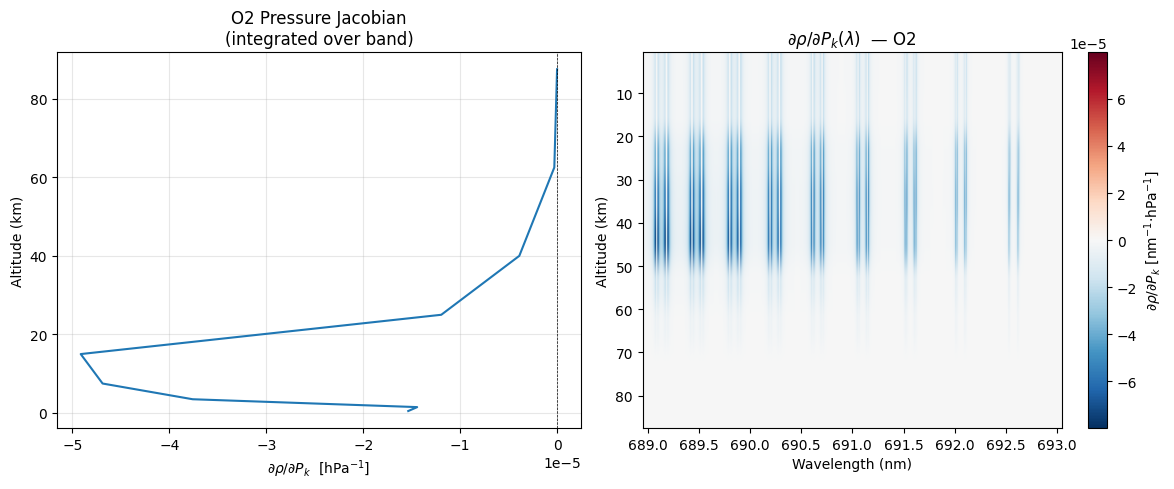

CPU times: user 407 ms, sys: 7.68 ms, total: 415 ms
Wall time: 420 ms


In [12]:
%%time
# Pressure Jacobian  ∂ρ/∂P_k  via finite-difference + chain rule
# Inherits: sfac, VMR_profile, NL_layers, T_mid, P_mid, n_mid, wl_hr (cell 4)
# Reuses  : dI_dkabs (cell 11)
#
# ΔP = 1 hPa forward difference on RADIS pressure broadening
# n_mid kept fixed (pure spectroscopic sensitivity, not hydrostatic)

import warnings, logging, io, contextlib
import jax.numpy as jnp

DeltaP = 1.0   # hPa
_sink2 = io.StringIO()

kabs_P   = np.zeros((len(wl_hr), NL_layers), dtype='float32')
kabs_PdP = np.zeros_like(kabs_P)

with warnings.catch_warnings(), contextlib.redirect_stdout(_sink2), contextlib.redirect_stderr(_sink2):
    warnings.simplefilter('ignore')
    logging.disable(logging.CRITICAL)
    for k_idx in range(NL_layers):
        vmr_k = float(VMR_profile[k_idx])
        n_k   = vmr_k * n_mid[k_idx]

        s0 = sfac.eq_spectrum(Tgas=float(T_mid[k_idx]),
                              pressure=float(P_mid[k_idx]) * 1e-3,
                              mole_fraction=vmr_k)
        wn_s0, sig0 = s0.get('xsection')
        wl_s0 = 1e7 / wn_s0[::-1]
        kabs_P[:, k_idx] = np.interp(wl_hr, wl_s0, sig0[::-1]) * n_k * 1e5

        s1 = sfac.eq_spectrum(Tgas=float(T_mid[k_idx]),
                              pressure=(float(P_mid[k_idx]) + DeltaP) * 1e-3,
                              mole_fraction=vmr_k)
        wn_s1, sig1 = s1.get('xsection')
        wl_s1 = 1e7 / wn_s1[::-1]
        kabs_PdP[:, k_idx] = np.interp(wl_hr, wl_s1, sig1[::-1]) * n_k * 1e5

    logging.disable(logging.NOTSET)

# forward-difference ∂kabs/∂P  [km⁻¹ hPa⁻¹],  shape (NWL_HR, NL)
dkabs_dP   = (kabs_PdP - kabs_P) / DeltaP
dkabs_dP_j = jnp.array(dkabs_dP, dtype=jnp.float32)
print(f"dkabs_dP: {dkabs_dP.shape},  "
      f"max |∂kabs/∂P| = {float(np.abs(dkabs_dP).max()):.3e} km⁻¹/hPa")

# --- chain rule  ∂ρ/∂P_k(ν) = dI_dkabs[ν,k] * dkabs_dP[ν,k] -------------
dI_dkabs_j = jnp.array(dI_dkabs, dtype=jnp.float32)   # (NWL_HR, NL)
drho_dP_wl = dI_dkabs_j * dkabs_dP_j                   # (NWL_HR, NL)

dwl = float(wl_hr[1] - wl_hr[0])
drho_dP = jnp.sum(drho_dP_wl, axis=0) * dwl             # (NL,)
drho_dP = np.array(drho_dP)
print(f"∂ρ/∂P  profile: shape={drho_dP.shape}, "
      f"max |∂ρ/∂P| = {np.abs(drho_dP).max():.3e} hPa⁻¹")

# --- plot ------------------------------------------------------------------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax_P = axes[0]
ax_P.plot(drho_dP, z_mid, color='C0', lw=1.5)
ax_P.axvline(0, color='k', lw=0.5, ls='--')
ax_P.set_xlabel(r'$\partial\rho/\partial P_k$  [hPa$^{-1}$]')
ax_P.set_ylabel('Altitude (km)')
ax_P.set_title(f'{MOLECULE} Pressure Jacobian\n(integrated over band)')
ax_P.grid(True, alpha=0.3)

ax_2d = axes[1]
ext = [wl_hr[0], wl_hr[-1], z_mid[0], z_mid[-1]]
vmax = float(np.abs(drho_dP_wl).max())
im = ax_2d.imshow(drho_dP_wl.T, aspect='auto', origin='lower',
                  extent=ext, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax_2d, label=r'$\partial\rho/\partial P_k$ [nm$^{-1}$·hPa$^{-1}$]')
ax_2d.set_xlabel('Wavelength (nm)')
ax_2d.set_ylabel('Altitude (km)')
ax_2d.set_title(rf'$\partial\rho/\partial P_k(\lambda)$  — {MOLECULE}')

plt.tight_layout()
plt.show()


peak  ρ_Q   = 0.0000 … 0.0061
peak  ρ_U   = 0.0000 … 0.0069
peak  ρ_pol = 0.0092
peak  DoLP  = 0.2374
∂ρ_I/∂alb range: 0.0000 … 0.8894
∂ρ_Q/∂alb range: -0.0003 … -0.0000


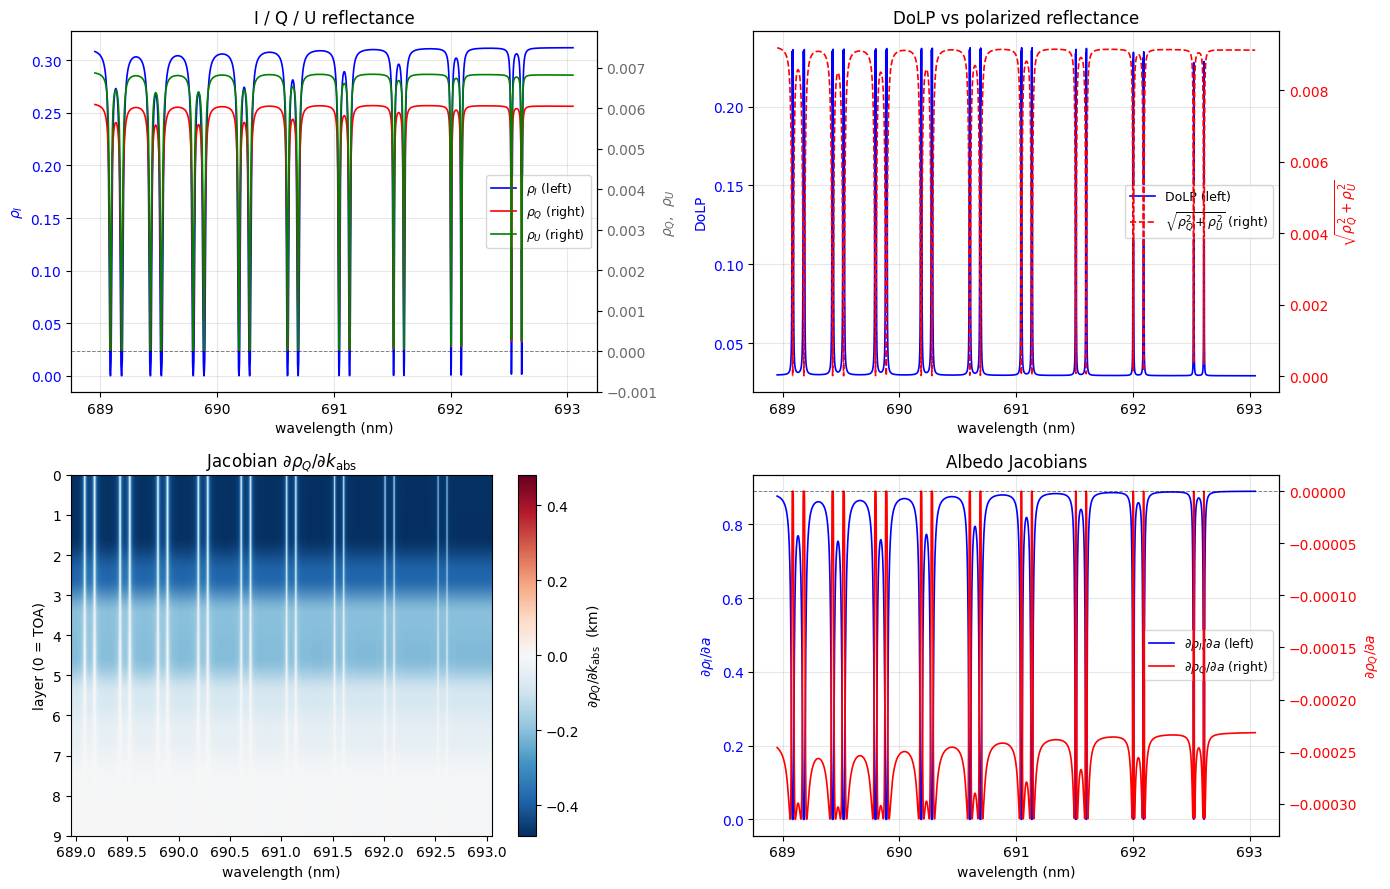

CPU times: user 1.11 s, sys: 245 ms, total: 1.35 s
Wall time: 1.25 s


In [13]:
%%time
# Polarized reflectance + Jacobians via analytic gradients
#
# Reuses _si_stokes, _N_h, NWL, NL_ defined in the previous cell.
#
# Analytic gradients of Si = sik · w_i · exp(-D_i · kabs) · alb^Ki :
#   ∂Si/∂kabs[l] = -D_i[l] · Si   →  ∂ρ/∂kabs[l] = -Σᵢ D_h[i,l]·sᵢ / N
#   ∂Si/∂alb     = (Ki/alb) · Si  →  ∂ρ/∂alb    =  Σᵢ nref_h[i]·sᵢ / (alb·N)
#
# fori_loop → XLA while_loop; no backward-pass checkpoint budget.
#   DoLP(ν) = √(ρ_Q² + ρ_U²) / ρ_I

def _body_pol(i, carry):
    rQ, rI, rU, dQk, dQa, dIa = carry
    kabs_i = kabs_j[i]
    wl_i   = wl_hr_j[i]
    alb_i  = alb_hr_j[i]

    si = _si_stokes(S_h, w_h, D_h, nref_h, wl_i, kabs_i, alb_i)   # (NStokes, NLE)

    rhoI = jnp.sum(si[0]) / _N_h
    rhoQ = jnp.sum(si[1]) / _N_h
    rhoU = jnp.sum(si[2]) / _N_h

    dQ_dkabs_i = -jnp.dot(D_h.T, si[1]) / _N_h          # (NL,)
    safe_alb   = jnp.where(alb_i > 0., alb_i, 1.)
    dQ_dalb_i  = jnp.dot(nref_h, si[1]) / (safe_alb * _N_h)
    dI_dalb_i  = jnp.dot(nref_h, si[0]) / (safe_alb * _N_h)

    return (
        rQ.at[i].set(rhoQ),
        rI.at[i].set(rhoI),
        rU.at[i].set(rhoU),
        dQk.at[i].set(dQ_dkabs_i),
        dQa.at[i].set(dQ_dalb_i),
        dIa.at[i].set(dI_dalb_i),
    )

init_pol = (
    jnp.zeros(NWL), jnp.zeros(NWL), jnp.zeros(NWL),
    jnp.zeros((NWL, NL_)), jnp.zeros(NWL), jnp.zeros(NWL),
)
rho_Q, rho_I, rho_U, dQ_dkabs, dQ_dalb, dI_dalb = jit(
    lambda: lax.fori_loop(0, NWL, _body_pol, init_pol)
)()

rho_Q    = np.array(rho_Q)
rho_U    = np.array(rho_U)
rho_I    = np.array(rho_I)
dQ_dkabs = np.array(dQ_dkabs)
dQ_dalb  = np.array(dQ_dalb)
dI_dalb  = np.array(dI_dalb)

rho_pol = np.sqrt(rho_Q**2 + rho_U**2)
DoLP    = rho_pol / np.maximum(rho_I, 1e-12)
print(f"peak  ρ_Q   = {rho_Q.min():.4f} … {rho_Q.max():.4f}")
print(f"peak  ρ_U   = {rho_U.min():.4f} … {rho_U.max():.4f}")
print(f"peak  ρ_pol = {rho_pol.max():.4f}")
print(f"peak  DoLP  = {DoLP.max():.4f}")
print(f"∂ρ_I/∂alb range: {dI_dalb.min():.4f} … {dI_dalb.max():.4f}")
print(f"∂ρ_Q/∂alb range: {dQ_dalb.min():.4f} … {dQ_dalb.max():.4f}")

# --- plots (2×2 layout) ---------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ── [0,0] I / Q / U reflectance ───────────────────────────────────────────
ax0  = axes[0, 0]
ax0r = ax0.twinx()
l1, = ax0.plot( wl_hr, rho_I, 'b',  lw=1.2, label=r'$\rho_I$ (left)')
l2, = ax0r.plot(wl_hr, rho_Q, 'r',  lw=1.2, label=r'$\rho_Q$ (right)')
l3, = ax0r.plot(wl_hr, rho_U, 'g',  lw=1.2, label=r'$\rho_U$ (right)')
ax0r.axhline(0, color='k', lw=0.7, ls='--', alpha=0.5)
_qu_lo = min(rho_Q.min(), rho_U.min())
_qu_hi = max(rho_Q.max(), rho_U.max())
_pad   = (_qu_hi - _qu_lo) * 0.15 if _qu_hi != _qu_lo else max(abs(_qu_hi), 1e-12) * 0.15
ax0r.set_ylim(_qu_lo - _pad, _qu_hi + _pad)
ax0.set_xlabel('wavelength (nm)')
ax0.set_ylabel(r'$\rho_I$', color='b')
ax0.tick_params(axis='y', labelcolor='b')
ax0r.set_ylabel(r'$\rho_Q$,  $\rho_U$', color='dimgrey')
ax0r.tick_params(axis='y', labelcolor='dimgrey')
ax0.set_title('I / Q / U reflectance')
ax0.legend(handles=[l1, l2, l3], fontsize=9, loc='best')
ax0.grid(True, alpha=0.3)

# ── [0,1] DoLP (left) + sqrt(Q²+U²) (right) ──────────────────────────────
ax1  = axes[0, 1]
ax1r = ax1.twinx()
l4, = ax1.plot( wl_hr, DoLP,    'b',   lw=1.2, label=r'DoLP (left)')
l5, = ax1r.plot(wl_hr, rho_pol, 'r--', lw=1.2, label=r'$\sqrt{\rho_Q^2+\rho_U^2}$ (right)')
ax1.set_xlabel('wavelength (nm)')
ax1.set_ylabel('DoLP', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1r.set_ylabel(r'$\sqrt{\rho_Q^2+\rho_U^2}$', color='r')
ax1r.tick_params(axis='y', labelcolor='r')
ax1.set_title('DoLP vs polarized reflectance')
ax1.legend(handles=[l4, l5], fontsize=9, loc='best')
ax1.grid(True, alpha=0.3)

# ── [1,0] Jacobian ∂ρ_Q/∂kabs (heatmap) ──────────────────────────────────
ax2 = axes[1, 0]
vmax = float(np.abs(dQ_dkabs).max())
im = ax2.imshow(dQ_dkabs.T, aspect='auto', origin='upper',
                extent=[wl_hr[0], wl_hr[-1], dQ_dkabs.shape[1], 0],
                cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax2, label=r'$\partial\rho_Q/\partial k_\mathrm{abs}$  (km)')
ax2.set_xlabel('wavelength (nm)'); ax2.set_ylabel('layer (0 = TOA)')
ax2.set_title(r'Jacobian $\partial\rho_Q/\partial k_\mathrm{abs}$')

# ── [1,1] Albedo Jacobians ────────────────────────────────────────────────
ax3  = axes[1, 1]
ax3r = ax3.twinx()
l6, = ax3.plot( wl_hr, dI_dalb, 'b',  lw=1.2, label=r'$\partial\rho_I/\partial a$ (left)')
l7, = ax3r.plot(wl_hr, dQ_dalb, 'r',  lw=1.2, label=r'$\partial\rho_Q/\partial a$ (right)')
ax3r.axhline(0, color='k', lw=0.7, ls='--', alpha=0.5)
ax3.set_xlabel('wavelength (nm)')
ax3.set_ylabel(r'$\partial\rho_I/\partial a$', color='b')
ax3.tick_params(axis='y', labelcolor='b')
ax3r.set_ylabel(r'$\partial\rho_Q/\partial a$', color='r')
ax3r.tick_params(axis='y', labelcolor='r')
ax3.set_title('Albedo Jacobians')
ax3.legend(handles=[l6, l7], fontsize=9, loc='best')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# AMFs

Single-scatter AMF = 3.1547  |  nscl=10

lay    Δz(km)       AMF    σ(AMF)     CV%
  0    25.000    3.1547    0.0000     0.0
  1    25.000    3.1549    0.0512     1.6
  2    20.000    3.1759    1.2092    38.1
  3    10.000    3.2429    2.3882    73.6
  4    10.000    3.3299    2.4424    73.3
  5     5.000    3.4310    2.3696    69.1
  6     3.000    3.5578    2.9651    83.3
  7     1.000    3.6940    3.0815    83.4
  8     1.000    3.9262    3.0970    78.9


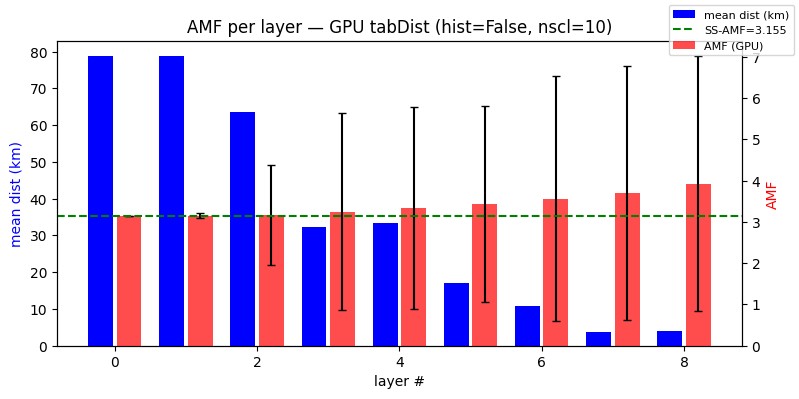

In [14]:
# ─── AMF from GPU tabDist (hist=False) ────────────────────────────────────
# compute_amf detects 'cdist_up (TOA)' in m_amf and reads GPU moments directly.
amf_gpu, thick_amf, cdist_gpu = compute_amf(m_amf)

AMF       = amf_gpu['AMF']
std_AMF   = amf_gpu['std_AMF']
has_scl   = 'AMF_cls' in amf_gpu
nscl_gpu  = amf_gpu['W_cls'].shape[1] if has_scl else 1

# Single-scatter AMF for reference
sza_rad = SZA * np.pi / 180
vza_rad = le['th'][0]
AMF_ss  = 1./np.cos(sza_rad) + 1./np.cos(vza_rad)
print(f"Single-scatter AMF = {AMF_ss:.4f}  |  nscl={nscl_gpu}")

# Report
print(f"\n{'lay':>3s}  {'Δz(km)':>8s}  {'AMF':>8s}  {'σ(AMF)':>8s}  {'CV%':>6s}")
for i in range(len(AMF)):
    cv = 100*std_AMF[i]/AMF[i] if AMF[i] > 0 else 0.
    print(f"{i:3d}  {thick_amf[i]:8.3f}  {AMF[i]:8.4f}  {std_AMF[i]:8.4f}  {cv:6.1f}")

# Plot
fig, ax1 = plt.subplots(figsize=(8, 4))
x   = np.arange(len(AMF))
ax2 = ax1.twinx()
ax1.bar(x - 0.2, amf_gpu['mean_dist'], color='b', width=0.35, label='mean dist (km)')
ax2.bar(x + 0.2, AMF, color='r', width=0.35, alpha=0.7, label='AMF (GPU)')
ax2.errorbar(x + 0.2, AMF, yerr=std_AMF, fmt='none', ecolor='k', capsize=3)
ax2.axhline(AMF_ss, color='green', ls='--', lw=1.5, label=f'SS-AMF={AMF_ss:.3f}')
ax1.set_xlabel('layer #'); ax1.set_ylabel('mean dist (km)', color='b')
ax2.set_ylabel('AMF', color='r'); ax2.set_ylim(bottom=0)
ax1.set_title(f'AMF per layer — GPU tabDist (hist=False, nscl={nscl_gpu})')
fig.legend(loc='upper right', fontsize=8)
plt.tight_layout()

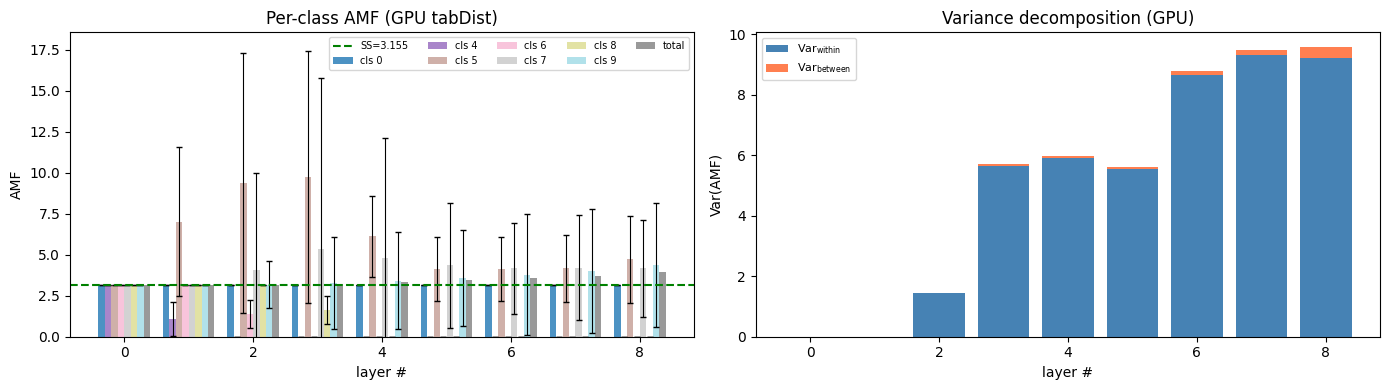

In [15]:
# ─── Per-scatter-class AMF breakdown (hist=False, GPU) ────────────────────
if has_scl:
    AMF_cls     = amf_gpu['AMF_cls']           # (NL, nscl)
    std_AMF_cls = amf_gpu.get('std_AMF_cls', np.zeros_like(AMF_cls))
    W_cls       = amf_gpu['W_cls']             # (NL, nscl)
    var_within  = amf_gpu.get('var_within',  np.zeros_like(AMF))
    var_between = amf_gpu.get('var_between', np.zeros_like(AMF))

    cmap       = plt.get_cmap('tab20', nscl_gpu)
    active_cls = [j for j in range(nscl_gpu) if np.any(W_cls[:, j] > 0)]
    nc         = len(active_cls)
    bw         = 0.8 / (nc + 1)

    fig, (ax_amf, ax_var) = plt.subplots(1, 2, figsize=(14, 4))
    for k, j in enumerate(active_cls):
        offset = (k - nc / 2) * bw
        mask = W_cls[:, j] > 0
        ax_amf.bar(x[mask] + offset, AMF_cls[mask, j], width=bw,
                   color=cmap(j), alpha=0.8, label=f'cls {j}')
        ax_amf.errorbar(x[mask] + offset, AMF_cls[mask, j],
                        yerr=std_AMF_cls[mask, j],
                        fmt='none', ecolor='k', capsize=2, lw=0.8)
    ax_amf.bar(x + (nc/2)*bw, AMF, width=bw, color='k', alpha=0.4, label='total')
    ax_amf.axhline(AMF_ss, color='green', ls='--', lw=1.5, label=f'SS={AMF_ss:.3f}')
    ax_amf.set_xlabel('layer #'); ax_amf.set_ylabel('AMF')
    ax_amf.set_title('Per-class AMF (GPU tabDist)')
    ax_amf.legend(fontsize=7, ncol=min(nc + 2, 5)); ax_amf.set_ylim(bottom=0)

    ax_var.bar(x, var_within  / thick_amf**2, color='steelblue',
               label=r'Var$_\mathrm{within}$')
    ax_var.bar(x, var_between / thick_amf**2, color='coral',
               bottom=var_within / thick_amf**2,
               label=r'Var$_\mathrm{between}$')
    ax_var.set_xlabel('layer #'); ax_var.set_ylabel('Var(AMF)')
    ax_var.set_title('Variance decomposition (GPU)')
    ax_var.legend(fontsize=8)
    plt.tight_layout()

## AMF post-hoc from photon histories (JAX)

Replicate the GPU `tabDist` accumulation using only the existing ALIS history buffer — no extra GPU simulation required.  
Supports the same options as `Smartg(amf_variance=, nscl=, norders=, scatter_classes=, cdist_wabs=)`.

**Per-photon effective weight** (mirrors `w_n = weight * wsca_ref * (st.x+st.y)` in `device.cu`):

$$w_i = S_I^{(i)} \cdot w_\mathrm{sca}(\lambda_\mathrm{ref})^{(i)} \cdot a^{K_i}  \cdot \underbrace{e^{-\sum_l D_l^{(i)}\,k_\mathrm{abs}(\lambda_\mathrm{ref},l)}}_{\texttt{cdist\_wabs=True only}}$$

**Scatter-class assignment** (identical to `device.cu`, `SCL_MODEd`):

| `scatter_classes` | class index $c_i$ |
|---|---|
| `'last_scattering_layer'` | $\lfloor l_\mathrm{scat} \cdot N_\mathrm{scl} / N_\mathrm{atm} \rfloor$ |
| `'scattering_order'` | $\min(n_\mathrm{int},\,N_\mathrm{scl})-1$ |
| `'scattering_order_per_layer'` | $l_\mathrm{scat}\cdot N_\mathrm{ord} + \min(n_\mathrm{int}-1,\,N_\mathrm{ord}-1)$ |

**cdist moments and AMF**:

$$\mathrm{cdist}[l,c,0]=\sum_i w_i,\quad \mathrm{cdist}[l,c,1]=\sum_i D_l^{(i)} w_i,\quad \mathrm{cdist}[l,c,2]=\sum_i (D_l^{(i)})^2 w_i$$

$$\mathrm{AMF}_l = \frac{\mathrm{cdist}[l,1]}{\mathrm{cdist}[l,0]\,\Delta z_l}, \qquad \sigma^2(\mathrm{AMF}_l) = \frac{\mathrm{cdist}[l,2]/\mathrm{cdist}[l,0] - \langle D_l\rangle^2}{\Delta z_l^2}$$

In [23]:
%%time
# ─── hist=True: same AMF via compute_amf — no extra GPU simulation needed ─
# compute_amf detects 'histories' in m_hist and computes cdist post-hoc.
# nscl defined in cell 10 — same value as used for the GPU run (cell 12).
wl_ref_h = float(np.median(wl_lr_r))    # band-centre reference wavelength

amf_hist, thick_h, cdist_hist = compute_amf(
    m_hist,
    wl_ref          = wl_ref_h,
    alb_ref         = ALBEDO,
    amf_variance    = True,
    nscl            = nscl,              # same as Samf compile option
    scatter_classes = 'scattering_order_per_layer',
    norders         = 2,
)
AMF_h     = amf_hist['AMF']
std_AMF_h = amf_hist['std_AMF']
print(f"cdist shape (hist=True)  = {cdist_hist.shape}")
print(f"cdist shape (hist=False) = {cdist_gpu.shape}")

cdist shape (hist=True)  = (9, 10, 3)
cdist shape (hist=False) = (9, 10, 3)
CPU times: user 1.09 s, sys: 47.2 ms, total: 1.14 s
Wall time: 944 ms



lay     AMF_GPU    AMF_hist      Δrel%    σ_hist
  0      3.1547      3.1547      0.00%    0.0000
  1      3.1549      3.1549      0.00%    0.0000
  2      3.1759      3.1764      0.01%    0.0000
  3      3.2429      3.2436      0.02%    0.0000
  4      3.3299      3.3301      0.01%    0.0000
  5      3.4310      3.4330      0.06%    0.0000
  6      3.5578      3.5563     -0.04%    0.0000
  7      3.6940      3.6935     -0.01%    0.0000
  8      3.9262      3.9292      0.08%    0.0000


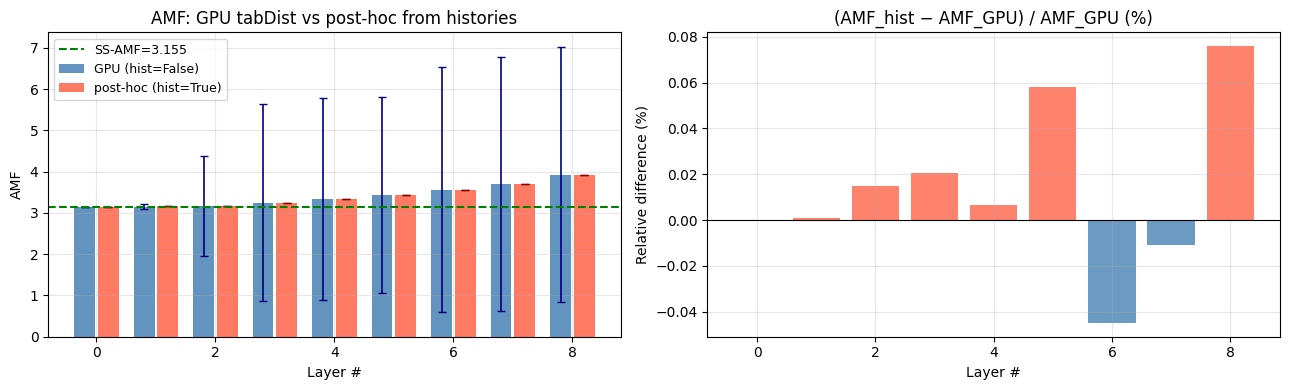

In [17]:
# ─── Comparison: hist=False (GPU tabDist) vs hist=True (post-hoc) ─────────
print(f"\n{'lay':>3s}  {'AMF_GPU':>10s}  {'AMF_hist':>10s}  {'Δrel%':>9s}  {'σ_hist':>8s}")
for i in range(len(AMF_h)):
    rel = 100. * (AMF_h[i] - AMF[i]) / AMF[i] if AMF[i] > 0 else 0.
    print(f"{i:3d}  {AMF[i]:10.4f}  {AMF_h[i]:10.4f}  {rel:8.2f}%  {std_AMF_h[i]:8.4f}")

x_c = np.arange(len(AMF_h))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.bar(x_c - 0.2, AMF,   width=0.35, color='steelblue', alpha=0.85, label='GPU (hist=False)')
ax1.bar(x_c + 0.2, AMF_h, width=0.35, color='tomato',    alpha=0.85, label='post-hoc (hist=True)')
ax1.errorbar(x_c - 0.2, AMF,   yerr=std_AMF,   fmt='none', ecolor='navy',    capsize=3, lw=1.2)
ax1.errorbar(x_c + 0.2, AMF_h, yerr=std_AMF_h, fmt='none', ecolor='darkred', capsize=3, lw=1.2)
ax1.axhline(AMF_ss, color='green', ls='--', lw=1.5, label=f'SS-AMF={AMF_ss:.3f}')
ax1.set_xlabel('Layer #'); ax1.set_ylabel('AMF')
ax1.set_title('AMF: GPU tabDist vs post-hoc from histories')
ax1.legend(fontsize=9); ax1.set_ylim(bottom=0); ax1.grid(True, alpha=0.3)

rel_diff = 100. * (AMF_h - AMF) / np.where(AMF > 0, AMF, 1.)
ax2.bar(x_c, rel_diff,
        color=['tomato' if v >= 0 else 'steelblue' for v in rel_diff], alpha=0.8)
ax2.axhline(0, color='k', lw=0.8)
ax2.set_xlabel('Layer #'); ax2.set_ylabel('Relative difference (%)')
ax2.set_title('(AMF_hist − AMF_GPU) / AMF_GPU (%)')
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [21]:
# ─── Per-scatter-class AMF breakdown (hist=True, post-hoc) ────────────────
if 'AMF_cls' in amf_hist:
    AMF_cls_h     = amf_hist['AMF_cls']           # (NL, nscl)
    std_AMF_cls_h = amf_hist.get('std_AMF_cls', np.zeros_like(AMF_cls_h))
    W_cls_h       = amf_hist['W_cls']             # (NL, nscl)
    nscl_h        = AMF_cls_h.shape[1]

    x_h       = np.arange(len(AMF_h))
    cmap_h    = plt.get_cmap('tab20', nscl_h)
    active_h  = [j for j in range(nscl_h) if np.any(W_cls_h[:, j] > 0)]
    na_h      = len(active_h)
    bw_h      = 0.8 / (na_h + 1)

    fig3, (ax_amf_h, ax_std_h) = plt.subplots(1, 2, figsize=(14, 4))
    fig3.suptitle(f"Post-hoc AMF per scatter class  "
                  f"(scattering_order_per_layer, nscl={nscl_h}, norders=2)",
                  fontsize=11)
    for k, j in enumerate(active_h):
        offset = (k - na_h / 2) * bw_h
        mask   = W_cls_h[:, j] > 0
        ax_amf_h.bar(x_h[mask] + offset, AMF_cls_h[mask, j],
                     width=bw_h, color=cmap_h(j), alpha=0.8, label=f'cls {j}')
        ax_std_h.bar(x_h[mask] + offset, std_AMF_cls_h[mask, j],
                     width=bw_h, color=cmap_h(j), alpha=0.8, label=f'cls {j}')
    ax_amf_h.bar(x_h + (na_h/2)*bw_h, AMF_h, width=bw_h, color='k', alpha=0.45, label='total')
    ax_amf_h.axhline(AMF_ss, color='green', ls='--', lw=1.5, label=f'SS-AMF={AMF_ss:.3f}')
    ax_amf_h.set_xlabel('Layer #'); ax_amf_h.set_ylabel('AMF')
    ax_amf_h.set_title('Mean AMF per scatter class (post-hoc)')
    ax_amf_h.legend(fontsize=7, ncol=min(na_h + 2, 5)); ax_amf_h.set_ylim(bottom=0)
    ax_std_h.bar(x_h + (na_h/2)*bw_h, std_AMF_h, width=bw_h, color='k', alpha=0.45, label='total')
    ax_std_h.set_xlabel('Layer #'); ax_std_h.set_ylabel(r'$\sigma$(AMF)')
    ax_std_h.set_title(r'$\sigma$(AMF) per scatter class (post-hoc)')
    ax_std_h.legend(fontsize=7, ncol=min(na_h + 2, 5))
    plt.tight_layout(); plt.show()
else:
    print("nscl=1 — no scatter-class breakdown.")

nscl=1 — no scatter-class breakdown.
